<a href="https://colab.research.google.com/github/Rogerio-mack/IMT_CD_2026/blob/main/IMT_ex_avaliativo_4_testes_de_significancia_solucao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<head>
  <meta name="author" content="Rogério de Oliveira">
  <meta institution="author" content="ITM">
</head>

<img src="https://maua.br/images/selo-60-anos-maua.svg" width=300, align="right">
<!-- <h1 align=left><font size = 6, style="color:rgb(200,0,0)"> optional title </font></h1> -->


In [47]:
#@markdown Nome **COMPLETO** e RA

Nome = 'Anna Karenina' #@param {type:"string"}
RA = '22.01164-0' #@param {type:"string"}
#@markdown

suffix_file = RA.replace('.','')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = 'https://github.com/Rogerio-mack/IMT_CD_2026/raw/main/data/'

#@markdown Execute para prosseguir...

In [48]:
#@markdown gera_df_stats_latex
from IPython.display import display, Latex, HTML
import warnings

def gera_df_stats_latex(df_stats, titulo):

  warnings.filterwarnings('ignore')
  # latex_table = df_stats.style.to_latex(hrules=True)
  latex_table = df_stats.to_latex(index=None)
  # display(Latex(latex_table))

  latex_table = latex_table.replace('tabular','array')
  latex_table = latex_table.replace('toprule','hline')
  latex_table = latex_table.replace('midrule','hline')
  latex_table = latex_table.replace('bottomrule','hline')

  latex_table = '\\textbf{' + titulo + '} \\\\' + latex_table

  warnings.filterwarnings('default')
  return latex_table

# **CASE: Treinamento**

Você está interessado em saber se um treinamento realizado com os funcionários da sua companhia será de fato efetivo para diminuir o tempo de realização de uma determinada tarefa realizada pelos funcionários. Você então coleta uma pequena amostra de 30 casos com o tempo dessa tarefa para os funcionários, antes e depois do treinamento. O resultado da coleta encontra-se abaixo.



In [49]:
df = pd.read_csv(path + 'task_before_after.csv',index_col=0)
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
After Hours,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,...,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00
Before Hours,1.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,...,0.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00
After Min,14.64,58.02,56.29,3.17,40.72,51.09,48.63,58.78,9.89,29.93,...,5.57,4.28,35.91,51.02,53.69,47.79,53.19,46.22,17.76,13.23
Before Min,13.42,44.20,56.20,6.38,14.60,17.13,21.64,3.23,10.58,51.10,...,56.87,25.22,0.73,4.80,8.86,3.78,45.53,51.10,11.56,21.42


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Q1.

Verifique estatisticamente os pressupostos para escolha do teste adequado.


## Normalidade

Primeiro uma inspeção visual em seguida um teste de Shapiro-Wilk parece mais adequado, sendo a amostra pequena ($\le$ 30).

In [50]:
df_antes = df[(df.index == 'Before Hours') | (df.index == 'Before Min')]
antes = 60 * df_antes.iloc[0,:] + df_antes.iloc[1,:]

df_depois = df[(df.index == 'After Hours') | (df.index == 'After Min')]
depois = 60 * df_depois.iloc[0,:] + df_depois.iloc[1,:]

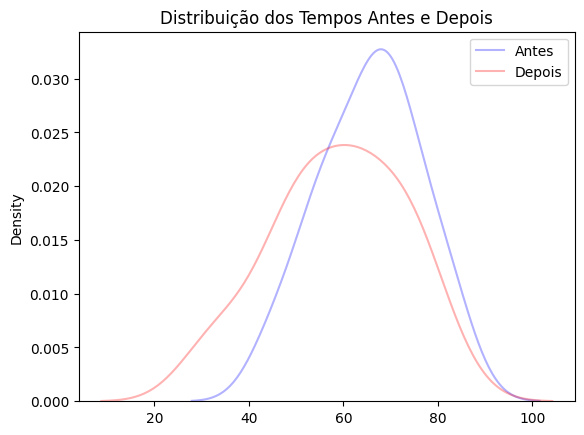

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


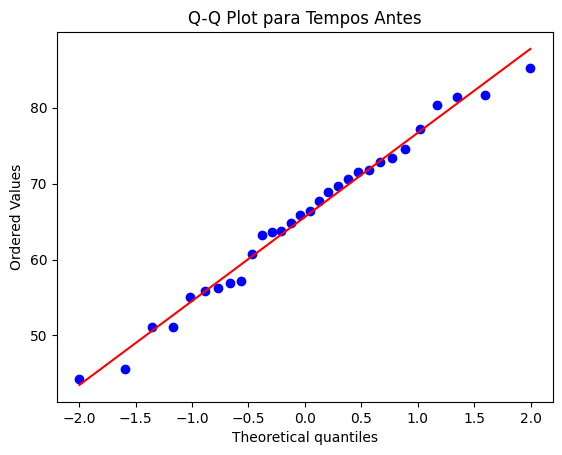

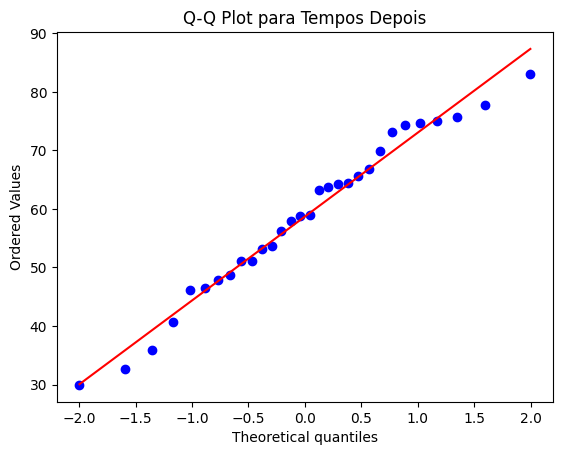

In [51]:
import scipy.stats as stats

sns.kdeplot(antes, color='blue', label='Antes',alpha=0.3)
sns.kdeplot(depois, color='red', label='Depois',alpha=0.3)
plt.legend()
plt.title('Distribuição dos Tempos Antes e Depois')
plt.show()

# Q-Q Plot
stats.probplot(antes, dist="norm", plot=plt)
plt.title('Q-Q Plot para Tempos Antes')
plt.show()

stats.probplot(depois, dist="norm", plot=plt)
plt.title('Q-Q Plot para Tempos Depois')
plt.show()


In [52]:
import scipy.stats as stats

stat, p = stats.shapiro(antes)

print(f'p-valor: {p:.3f}')

if p > 0.05:
    print('Não se pode rejeitar a hipótese nula de normalidade (p > 0.05).')
else:
    print('Rejeita-se a hipótese nula de normalidade (p <= 0.05).')

stats, p = stats.shapiro(depois)

print(f'p-valor: {p:.3f}')

if p > 0.05:
    print('Não se pode rejeitar a hipótese nula de normalidade (p > 0.05).')
else:
    print('Rejeita-se a hipótese nula de normalidade (p <= 0.05).')

p-valor: 0.820
Não se pode rejeitar a hipótese nula de normalidade (p > 0.05).
p-valor: 0.609
Não se pode rejeitar a hipótese nula de normalidade (p > 0.05).


## Variâncias iguais

Tendo os dados distribuição normal o teste de variâncias iguais mais indicado é o bartlett.


In [53]:
import scipy.stats as stats

stat, p = stats.bartlett(antes, depois)

print(f'p-valor: {p:.3f}')

if p > 0.05:
    print('Não se pode rejeitar a hipótese nula de igualdade de variâncias (p > 0.05).')
else:
    print('Rejeita-se a hipótese nula de igualdade de variâncias (p <= 0.05).')

p-valor: 0.165
Não se pode rejeitar a hipótese nula de igualdade de variâncias (p > 0.05).


Desse modo, o dado atende o pressuposto dos **testes paramétricos.** Sendo os dados **pareados**, deve-se empregar o teste t pareado `ttest_rel`.

In [54]:
#
# Digite suas respostas conforme o exemplo
#
Q1 = {}
Q1['a. Teste de Normalidade'] =  'shapiro' # string
Q1['p-value dados 1'] =  0.820
Q1['p-value dados 2'] =  0.609

Q1['b. Teste de Variância'] =  'bartlett' # string
Q1['p-value'] = 0.165

Q1['Teste Selecionado para a tarefa'] = 'ttest_rel' # string

# Q2.

A partir do teste selecionado verifique se o treinamento:

> a. Altera o tempo para realização da tarefa

> b. De fato, reduz o tempo para realização da tarefa



Primeiro, podemos fazer uma inspeção visual para ver se faz sentido.

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


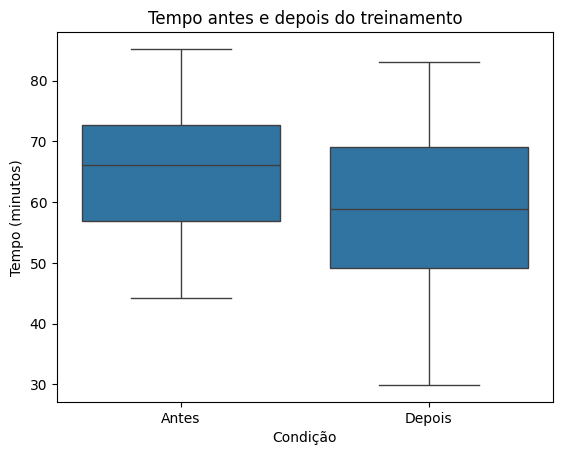

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [55]:
df_boxplot = pd.DataFrame({
    'Tempo': np.concatenate([antes, depois]),
    'Condição': ['Antes'] * len(antes) + ['Depois'] * len(depois)})

sns.boxplot(x='Condição', y='Tempo', data=df_boxplot)
plt.xlabel('Condição')
plt.ylabel('Tempo (minutos)')
plt.title('Tempo antes e depois do treinamento')
plt.show()


In [56]:
import scipy.stats as stats

# 1. Verificar se as séries 'antes' e 'depois' são estatisticamente diferentes (teste bilateral)
stat, p = stats.ttest_rel(antes, depois)

print(f'p-valor: {p:.3f}')

if p < 0.05:
    print('Há uma diferença estatisticamente significativa entre as séries (p < 0.05).')
else:
    print('Não há diferença estatisticamente significativa entre as séries (p >= 0.05).')

# 2. Verificar se 'depois' é menor que 'antes' (teste unilateral)
# H0: media_depois >= media_antes (ou media_antes - media_depois <= 0)
# Ha: media_depois < media_antes (ou media_antes - media_depois > 0)

# Como ttest_rel(a, b) testa se mean(a) - mean(b) != 0, um t > 0 apoia mean(a) > mean(b)
# Portanto, se stat_diff > 0 e p_diff/2 < alpha, então 'antes' > 'depois' (ou 'depois' < 'antes')

p_one_sided = p / 2

print(f'p-valor unilateral: {p_one_sided:.3f}')

if stat > 0 and p_one_sided < 0.05:
    print('Há evidência de que o tempo "depois" é menor que o tempo "antes" (p < 0.05).')
else:
    print('Não há evidência de que o tempo "depois" é menor que o tempo "antes" (p >= 0.05).')


p-valor: 0.012
Há uma diferença estatisticamente significativa entre as séries (p < 0.05).
p-valor unilateral: 0.006
Há evidência de que o tempo "depois" é menor que o tempo "antes" (p < 0.05).


In [57]:
stat, p_one_sided = stats.ttest_rel(depois, antes, alternative='less') # stats.ttest_rel(a, b, alternative='less'), Ha a < b
# stat, p_one_sided = stats.ttest_rel(antes, depois, alternative='greater')

print(f'p-valor unilateral: {p_one_sided:.3f}')

if p_one_sided < 0.05:
    print('Há evidência de que o tempo "depois" é menor que o tempo "antes" (p < 0.05).')
else:
    print('Não há evidência de que o tempo "depois" é menor que o tempo "antes" (p >= 0.05).')

p-valor unilateral: 0.006
Há evidência de que o tempo "depois" é menor que o tempo "antes" (p < 0.05).


In [58]:
#
# Digite suas respostas conforme o exemplo
#
Q2 = {}
Q2['a. Altera o tempo para realização da tarefa?'] =  'sim' # 'sim' ou 'não'
Q2['a. p-value'] =  0.012

Q2['b. Reduz o tempo para realização da tarefa?'] =  'sim ' # 'sim' ou 'não'
Q2['b. p-value'] =  0.006

# Q3.

Verifique as mesmas hipóteses acima, no caso de:

> a. Se o tempo após o treinamento fosse em média 3% maior, as conclusões seriam as mesmas? O treinamento reduziria o tempo para realização da tarefa?

> b. Se a amostra não fosse pareada, mas de 30 funcionários quaisquer. Ainda assim teríamos a mesma conclusão?

> c. As médias antes ou depois têm média estatisticamente iguais a 60min?



## Q3.a

In [59]:
stat, p = stats.ttest_rel(antes, 1.03*depois)

print(f'p-valor: {p:.3f}')

if p < 0.05:
    print('Há uma diferença estatisticamente significativa entre as séries (p < 0.05).')
else:
    print('Não há diferença estatisticamente significativa entre as séries (p >= 0.05).')

stat, p_one_sided = stats.ttest_rel(1.03*depois, antes, alternative='less') # stats.ttest_rel(a, b, alternative='less'), Ha a < b

print(f'p-valor unilateral: {p_one_sided:.3f}')

if p_one_sided < 0.05:
    print('Há evidência de que o tempo "depois" é menor que o tempo "antes" (p < 0.05).')
else:
    print('Não há evidência de que o tempo "depois" é menor que o tempo "antes" (p >= 0.05).')

p-valor: 0.059
Não há diferença estatisticamente significativa entre as séries (p >= 0.05).
p-valor unilateral: 0.029
Há evidência de que o tempo "depois" é menor que o tempo "antes" (p < 0.05).


## Q3.b

In [60]:
stat, p = stats.ttest_ind(antes, depois)

print(f'p-valor: {p:.3f}')

if p < 0.05:
    print('Há uma diferença estatisticamente significativa entre as séries (p < 0.05).')
else:
    print('Não há diferença estatisticamente significativa entre as séries (p >= 0.05).')

stat, p_one_sided = stats.ttest_ind(depois, antes, alternative='less') # stats.ttest_rel(a, b, alternative='less'), Ha a < b

print(f'p-valor unilateral: {p_one_sided:.3f}')

if p_one_sided < 0.05:
    print('Há evidência de que o tempo "depois" é menor que o tempo "antes" (p < 0.05).')
else:
    print('Não há evidência de que o tempo "depois" é menor que o tempo "antes" (p >= 0.05).')

p-valor: 0.035
Há uma diferença estatisticamente significativa entre as séries (p < 0.05).
p-valor unilateral: 0.018
Há evidência de que o tempo "depois" é menor que o tempo "antes" (p < 0.05).


Teste ind: 0.017701091007763025
Teste rel: 0.005784747574491202


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarni

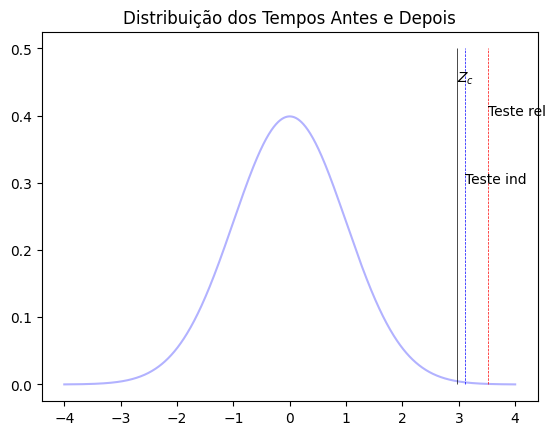

In [61]:
from scipy.stats import ttest_ind, ttest_rel, norm

_, p_valor_ind = ttest_ind(depois, antes, alternative='less')
_, p_valor_rel = ttest_rel(depois, antes, alternative='less')

print("Teste ind:", p_valor_ind)
print("Teste rel:", p_valor_rel)

sns.lineplot(x=np.linspace(-4,4,1000),y=norm.pdf(np.linspace(-4,4,1000)), color='blue', alpha=0.3)

plt.vlines(1-norm.ppf(p_valor_ind), ymin=0, ymax=0.5, colors='blue', linestyles='dashed',label='Teste ind',lw=0.5)
plt.vlines(1-norm.ppf(p_valor_rel), ymin=0, ymax=0.5, colors='red', linestyles='dashed',label='Teste rel',lw=0.5)
plt.vlines(1-norm.ppf(0.025), ymin=0, ymax=0.5, colors='k', label='Critical',lw=0.5)

plt.text(1-norm.ppf(p_valor_ind), 0.3,'Teste ind')
plt.text(1-norm.ppf(p_valor_rel), 0.4,'Teste rel')
plt.text(1-norm.ppf(0.025), 0.45,'$Z_c$')

# plt.legend(loc='upper left')
plt.title('Distribuição dos Tempos Antes e Depois')
plt.show()



$$ p_{rel} \le p_{ind} $$

Portanto,

> Se test_rel rejeita $\longrightarrow$ test_ind rejeita

> Se test_ind rejeita $\not \longrightarrow$ test_rel rejeita

E, portanto, aplicando um teste errado (não pareado para amostras pareadas), neste caso, posso estar gerar *falsos negativos*.

## Q3.c

In [62]:
import scipy.stats as stats

stat, p = stats.ttest_1samp(antes, 60)

print(f'p-valor: {p:.3f}')

if p < 0.05:
    print('Há uma diferença estatisticamente significativa da média de 60 minutos (p < 0.05).')
else:
    print('Não há diferença estatisticamente significativa da média de 60 minutos (p >= 0.05).')


p-valor: 0.008
Há uma diferença estatisticamente significativa da média de 60 minutos (p < 0.05).


In [63]:
import scipy.stats as stats

stat, p = stats.ttest_1samp(depois, 60)

print(f'p-valor: {p:.3f}')

if p < 0.05:
    print('Há uma diferença estatisticamente significativa da média de 60 minutos (p < 0.05).')
else:
    print('Não há diferença estatisticamente significativa da média de 60 minutos (p >= 0.05).')

p-valor: 0.613
Não há diferença estatisticamente significativa da média de 60 minutos (p >= 0.05).


In [64]:
#
# Digite suas respostas conforme o exemplo
#
Q3 = {}
Q3['a. (3% maior) Reduz o tempo para realização da tarefa?'] =  'sim' # 'sim' ou 'não'
Q3['a. p-value'] =  0.029

Q3['b. (não pareada) Reduz o tempo para realização da tarefa?'] =  'sim' # 'sim' ou 'não'
Q3['b. p-value'] =  0.018

Q3['c(1). Tempos "antes" têm média estatisticamente iguais a 60min?'] =  'não' # 'sim' ou 'não'
Q3['c(1). p-value'] =  0.008
Q3['c(2). Tempos "depois" têm média estatisticamente iguais a 60min?'] =  'sim' # 'sim' ou 'não'
Q3['c(2). p-value'] =  0.613

# **CASE: Game Analysis**

Um pesquisador está investigando a experiência de usuários em um jogo com diferentes dispositivos. Para isso ele selecionou alguns alunos da Universidade para testar os jogos. Cada jogador responde um questionário prévio com informações do seu perfil, realiza uma ou até 3 jogadas com os dispositivos *Skate*, *Joystick* e *Teclado*. Os dados do experimento estão abaixo.

In [65]:
df_games = pd.read_csv(path + 'df_games.csv')
df_pre_games_Q = pd.read_csv(path + 'df_pre_games_Q.csv')

display(df_games.head())
display(df_pre_games_Q.head())

,RA,pontuacao,tempo_obstaculo,tempo_total,device
0,21505616,2,12.44,12.44,skate
1,21505616,13,42.01,54.45,skate
2,21505616,26,49.09,103.54,skate
3,32143621,0,5.45,5.45,skate
4,32143621,3,13.99,19.44,skate


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Carimbo de data/hora,RA,Data de nascimento,Gênero,Frequência que anda de skate,Frequência que usa jogos de computador,Frequência que usa jogos de console (Xbox / Playstation / Wii),Frequência que usa jogos em dispositivos móveis (smartphone e/ou tablet),Gênero de jogo preferido
0,2023-08-21 16:47:52.279,42118816,2003-06-07,Feminino,Nunca,Regularmente (algumas vezes por semana),Regularmente (algumas vezes por semana),Nunca,"Ação e aventura, RPG, Simulação, Corrida, Estr..."
1,2023-08-22 13:49:56.703,42145333,2000-11-26,Masculino,Raramente (algumas vezes por ano),Regularmente (algumas vezes por semana),Raramente (algumas vezes por ano),Regularmente (algumas vezes por semana),"Ação e aventura, RPG, Estratégia"
2,2023-08-22 14:15:17.455,42326321,2004-11-29,Masculino,Nunca,Ocasionalmente (algumas vezes por mês),Raramente (algumas vezes por ano),Raramente (algumas vezes por ano),Esporte
3,2023-08-22 14:40:49.151,32339623,2004-07-13,Masculino,Nunca,Frequente (todos os dias),Regularmente (algumas vezes por semana),Raramente (algumas vezes por ano),"Ação e aventura, RPG, Estratégia, MOBA"
4,2023-08-22 15:08:53.471,42305535,2005-09-09,Masculino,Nunca,Ocasionalmente (algumas vezes por mês),Nunca,Ocasionalmente (algumas vezes por mês),RPG


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Q4.

Você interessado em saber se há diferença de desempenho (pontuação) significativa entre homens e mulheres no jogo ou por dispositivo.

Verifique **graficamente** os pressupostos para escolha do teste adequado (empregue os melhores gráficos para essa tarefa).


In [66]:
df = pd.merge(df_games, df_pre_games_Q[['RA','Gênero']], how='inner', on='RA')
df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,RA,pontuacao,tempo_obstaculo,tempo_total,device,Gênero
0,21505616,2,12.44,12.44,skate,Masculino
1,21505616,13,42.01,54.45,skate,Masculino
2,21505616,26,49.09,103.54,skate,Masculino
3,32143621,0,5.45,5.45,skate,Feminino
4,32143621,3,13.99,19.44,skate,Feminino


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


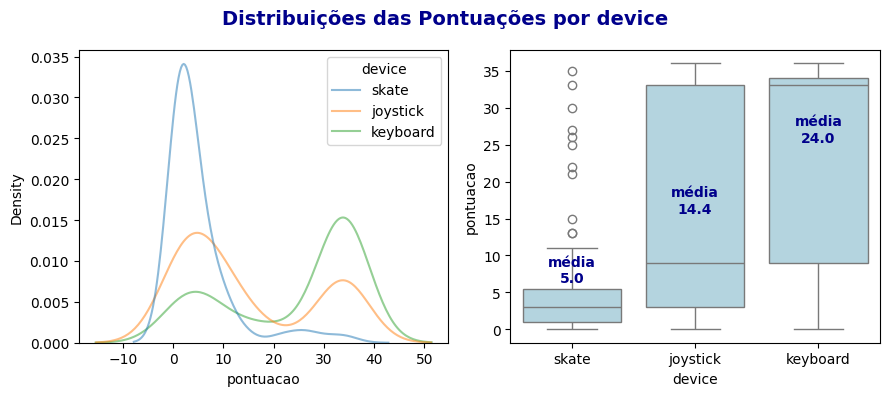

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


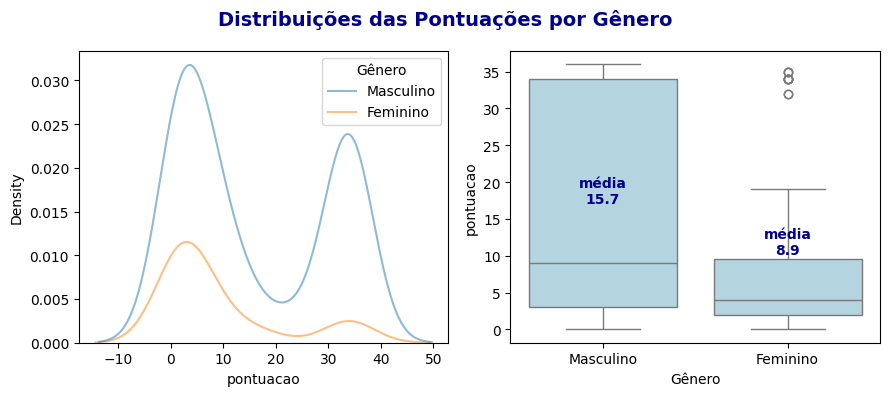

In [67]:
def plot_distribution(df,hue):

  fig, [ax1, ax2] = plt.subplots(1,2,figsize=(9,4))

  sns.kdeplot(x='pontuacao',data=df,hue=hue,ax=ax1,alpha=0.5)
  sns.boxplot(x=hue, y='pontuacao', data=df, color='lightblue',ax=ax2, orientation='vertical')

  # Adiciona valor das média ao gráfico
  medians = df.groupby(hue)['pontuacao'].mean()
  vertical_offset = df['pontuacao'].median() * 0.2 # offset from median for display

  for xtick in ax2.get_xticks():
      ax2.text(xtick, medians[ax2.get_xticklabels()[xtick].get_text()] + vertical_offset,
               "média\n" + str(np.round(medians[ax2.get_xticklabels()[xtick].get_text()],1)),
              horizontalalignment='center',size=10,color='darkblue',weight='bold')

  plt.suptitle('Distribuições das Pontuações por ' + hue,fontsize=14,weight='bold',color='darkblue')

  plt.tight_layout()
  plt.show()

  return

plot_distribution(df,'device')
plot_distribution(df,'Gênero')

Além da inspeção visual, podemos confirmar a não normalidade por um teste hipóteses. Como a amostra é significativa ($\gt \gt 30$), empregamos  o `normaltest`.  

In [68]:
import scipy.stats as stats

for device in df.device.unique():
  select_device = df['device'] == device
  for genero in df['Gênero'].unique():
    select_genero = df['Gênero'] == genero
    stat, p = stats.normaltest(df[select_genero & select_device]['pontuacao'])

    print(f'device: {device}, genero: {genero}')
    print(f'p-valor: {p:.3f}')

    if p > 0.05:
        print('Não se pode rejeitar a hipótese nula de normalidade (p > 0.05).')
    else:
        print('Rejeita-se a hipótese nula de normalidade (p <= 0.05).')

device: skate, genero: Masculino
p-valor: 0.000
Rejeita-se a hipótese nula de normalidade (p <= 0.05).
device: skate, genero: Feminino
p-valor: 0.001
Rejeita-se a hipótese nula de normalidade (p <= 0.05).
device: joystick, genero: Masculino
p-valor: 0.000
Rejeita-se a hipótese nula de normalidade (p <= 0.05).
device: joystick, genero: Feminino
p-valor: 0.000
Rejeita-se a hipótese nula de normalidade (p <= 0.05).
device: keyboard, genero: Masculino
p-valor: 0.000
Rejeita-se a hipótese nula de normalidade (p <= 0.05).
device: keyboard, genero: Feminino
p-valor: 0.000
Rejeita-se a hipótese nula de normalidade (p <= 0.05).


Não havendo uma distribuição normal dos dados, devemos  empregar um **teste não paramétrico**, para comparação de medianas de dados não pareados empregamos o `Mann-Whitney`.

In [69]:
#
# Digite suas respostas conforme o exemplo
#
Q4 = {}
Q4['Teste Selecionado para comparar pontuações por genêro'] = 'Mann-Whitney' # string
Q4['Teste Selecionado para comparar pontuações por dispositivo'] = 'Mann-Whitney' # string

# Q5.

Produza então uma tabela `df_stats` como abaixo empregando a função `gera_df_stats_latex(df_stats, titulo)` para avaliar se há diferença na pontuação de homens e mulheres para cada tipo de dispositivo e no geral.




In [70]:
from scipy.stats import mannwhitneyu

results = pd.DataFrame(columns=['device','stat Mann-Whitney','p-value','H0-Rejected'])

stat, p_valor = mannwhitneyu(df[df['Gênero'] == 'Feminino']['pontuacao'], df[df['Gênero'] == 'Masculino']['pontuacao'])
results.loc[len(results)] = ['all',np.round(stat,4),np.round(p_valor,4),p_valor < 0.05]

for device in df.device.unique():
  select = df['device'] == device
  stat, p_valor = mannwhitneyu(df[(df['Gênero'] == 'Feminino') & (select)]['pontuacao'], df[(df['Gênero'] == 'Masculino') & (select)]['pontuacao'])
  results.loc[len(results)] = [device,np.round(stat,4),np.round(p_valor,4),p_valor < 0.05]

  print('Device =', device)
  print("Estatística:", stat)
  print("Valor p:", p_valor)
  if p_valor < 0.05:
      print("Rejeitamos a hipótese nula - as distribuições dos dados são estatisticamente diferentes.")
  else:
      print("Não rejeitamos a hipótese nula - não há evidências suficientes para afirmar diferença nas distribuições dos dados.")
  print()

results

Device = skate
Estatística: 727.0
Valor p: 0.003047546798124285
Rejeitamos a hipótese nula - as distribuições dos dados são estatisticamente diferentes.

Device = joystick
Estatística: 792.0
Valor p: 0.0020410959936567282
Rejeitamos a hipótese nula - as distribuições dos dados são estatisticamente diferentes.

Device = keyboard
Estatística: 871.5
Valor p: 0.08760850621852327
Não rejeitamos a hipótese nula - não há evidências suficientes para afirmar diferença nas distribuições dos dados.



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,device,stat Mann-Whitney,p-value,H0-Rejected
0,all,7853.0,0.0003,True
1,skate,727.0,0.0030,True
2,joystick,792.0,0.0020,True
3,keyboard,871.5,0.0876,False


In [71]:
latex_results_scores = gera_df_stats_latex(results,'Game Analysis')
display(Latex(latex_results_scores))

<IPython.core.display.Latex object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [72]:
# Seu código

df_stats = pd.DataFrame(columns=['device','SeuTeste','p-value','H0-Rejected'])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [73]:
#
# Digite suas respostas conforme o exemplo
#
Q5 = {}
Q5['df_stats'] = df_stats # seu dataframe

# Q6.

(**Sem consulta** ... rs) Com base no exercício Q3.b, se empregamos erroneamente um teste não pareado em amostras pareadas a tendência é de gerarmos mais falsos positivos? Justifique explicando a relação com os p-valores.

In [74]:
Q6 = {
'''

Quando você utiliza um teste não pareado em dados que são pareados (dependentes) o p-valor é afetado.
Na maior parte das vezes é aumentado o p-valor no teste não pareado, com  aumento de falsos negativos (Erro Tipo II),
mas também é possível, a depender do dados, de ser reduzido, com aumento de falsos positivos (Erro Tipo I).

'''.replace('\n','')
}


In [75]:
#@markdown Execute para gerar e verificar suas respostas
import pickle
import numpy as np
import pandas as pd

# Create an example dictionary with complex objects
example_dict = {
    'Q1': Q1,
    'Q2': Q2,
    'Q3': Q3,
    'Q4': Q4,
    'Q5': Q5,
    'Q6': Q6
}

# Define the filename with .pkl extension
filename = 'P1_' + Nome.replace(' ','_') + '_' + RA + '.pkl'

# Serialize the dictionary to a pickle file
with open(filename, 'wb') as f:
      pickle.dump(example_dict, f)

from IPython.display import display, HTML

# display(HTML('<span style="font-family: Georgia; font-size: 24px; color: blue;">Respostas</span>'))
display(HTML('<span style="font-size: 24px; color: blue;">Respostas</span>'))
print()
for key, value in example_dict.items():
  if not isinstance(value, dict):
    print(f'{key}: {value}')
    print()
  else:
    print(f'{key}')
    for key2, value2 in value.items():
      print(f'{key2}: {value2}')
    print()

print()
display(HTML('<span style="font-size: 14px; color: blue;">Respostas salvas com sucesso em:</span>'))
print()
fname = f'<span style="font-size: 14px; color: blue;"><strong>{filename}</strong></span>'
display(HTML(fname))


Q1
a. Teste de Normalidade: shapiro
p-value dados 1: 0.82
p-value dados 2: 0.609
b. Teste de Variância: bartlett
p-value: 0.165
Teste Selecionado para a tarefa: ttest_rel

Q2
a. Altera o tempo para realização da tarefa?: sim
a. p-value: 0.012
b. Reduz o tempo para realização da tarefa?: sim 
b. p-value: 0.006

Q3
a. (3% maior) Reduz o tempo para realização da tarefa?: sim
a. p-value: 0.029
b. (não pareada) Reduz o tempo para realização da tarefa?: sim
b. p-value: 0.018
c(1). Tempos "antes" têm média estatisticamente iguais a 60min?: não
c(1). p-value: 0.008
c(2). Tempos "depois" têm média estatisticamente iguais a 60min?: sim
c(2). p-value: 0.613

Q4
Teste Selecionado para comparar pontuações por genêro: Mann-Whitney
Teste Selecionado para comparar pontuações por dispositivo: Mann-Whitney

Q5
df_stats: Empty DataFrame
Columns: [device, SeuTeste, p-value, H0-Rejected]
Index: []

Q6: {'Quando você utiliza um teste não pareado em dados que são pareados (dependentes) o p-valor é afetado.N

In [76]:
#@markdown Execute para fazer o download do arquivo com suas respostas
from google.colab import files
files.download(filename)


fname = f'<span style="font-size: 14px; color: blue;">Salve o arquivo {filename} para download.</strong></span>'
display(HTML(fname))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>